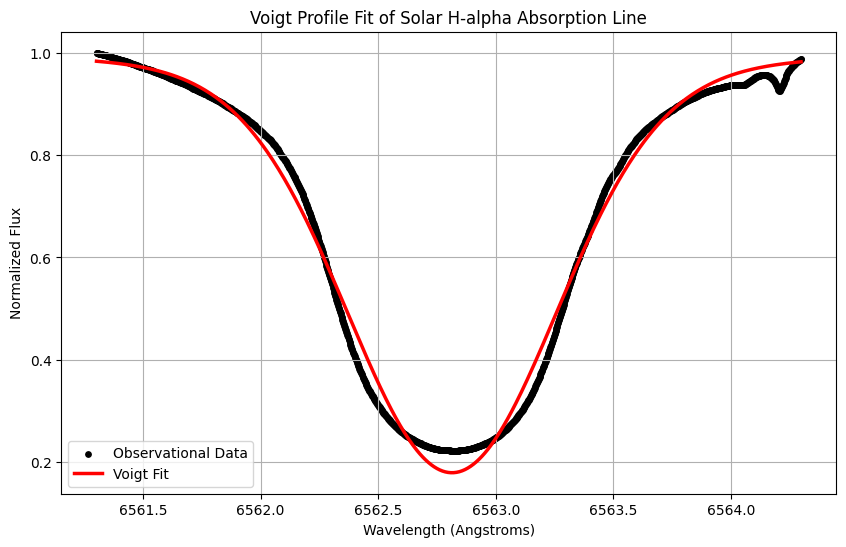

Gaussian Width (Sigma): 0.4179 A
Lorentzian Width (Gamma): 0.0796 A
Calculated Chromospheric Temperature: 22,083 K


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import voigt_profile

# Load visible solar spectrum data (BASS2000 Archive)
data = np.loadtxt('solar_spectrum.txt', delimiter=',', usecols=(0, 1))
wavelength = data[:, 0]
flux = data[:, 1]

# Isolate the H-alpha line (Rest wavelength: 6562.8 A)
# Constraining the window to 1.5 A to avoid telluric blending in the wings
center_wave = 6562.8
window = 1.5  
mask = (wavelength > center_wave - window) & (wavelength < center_wave + window)
x_clean = wavelength[mask]
y_clean = flux[mask]

# Local continuum normalization
y_clean = y_clean / np.max(y_clean)

def absorption_voigt(x, amplitude, center, sigma, gamma):
    """
    Computes an inverted Voigt profile for absorption line modeling.
    sigma: Gaussian broadening (Thermal)
    gamma: Lorentzian broadening (Pressure/Collisional)
    """
    return 1.0 - amplitude * voigt_profile(x - center, sigma, gamma)

# Fit parameters: [amplitude, center, sigma, gamma]
initial_guess = [0.8, center_wave, 0.1, 0.1]

# Set thermodynamic boundaries to prevent non-physical zero-width fitting
lower_bounds = [0.1, center_wave - 0.5, 0.01, 0.01]
upper_bounds = [2.0, center_wave + 0.5, 0.5, 1.0]

popt, pcov = curve_fit(
    absorption_voigt, 
    x_clean, 
    y_clean, 
    p0=initial_guess, 
    bounds=(lower_bounds, upper_bounds)
)

# Render and save the observational fit
plt.figure(figsize=(10, 6))
plt.scatter(x_clean, y_clean, s=15, color='black', label='Observational Data')

x_smooth = np.linspace(min(x_clean), max(x_clean), 500)
plt.plot(x_smooth, absorption_voigt(x_smooth, *popt), color='red', linewidth=2.5, label='Voigt Fit')

plt.title('Voigt Profile Fit of Solar H-alpha Absorption Line')
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Normalized Flux')
plt.legend()
plt.grid(True)
plt.savefig('voigt_plot.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Extract parameters and calculate chromospheric kinetic temperature
sigma_angstroms = popt[2]
lambda_0 = center_wave * 1e-10         
c = 299792458                          
k_B = 1.380649e-23                     
m_H = 1.6735575e-27                    
delta_lambda = sigma_angstroms * 1e-10 

temperature = ((delta_lambda * c / lambda_0)**2) * (m_H / (2 * k_B))

print(f"Gaussian Width (Sigma): {popt[2]:.4f} A")
print(f"Lorentzian Width (Gamma): {popt[3]:.4f} A")
print(f"Calculated Chromospheric Temperature: {temperature:,.0f} K")